# Mendeley datasets download via API

Get your Mendeley API token by registering an app here:

https://dev.mendeley.com/myapps.html

## Environment setup

In [16]:
import requests
from requests.auth import HTTPBasicAuth
from io import BytesIO
import os
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import random
import json
import truststore
from IPython.display import clear_output

ROOT = ".." # Adjust to repository root
DATASETS_DIR = os.path.join(ROOT, "datasets")
PKL_DIR = os.path.join(ROOT, "pkl")

from dotenv import load_dotenv
DOTENV_PATH = os.path.join(ROOT,"../../apis/.env") # Adjust to .env file location

if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    masked_parts = 2
    masked = '\\'.join(['***'] * masked_parts + abs_path.split('\\')[masked_parts:])
    print(f"Loaded .env from {masked}")
else:
    print("Failed to load .env file.")

CLIENT_ID = os.getenv("MENDELEY_CLIENT_ID")
CLIENT_SECRET = os.getenv("MENDELEY_CLIENT_SECRET")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"CLIENT_SECRET: {mask_token(CLIENT_SECRET)}")

Loaded .env from ***\***\.env
CLIENT_SECRET: hF8**********r63


## Worldwide Electricity Load Dataset

Ullah, Md Habib; Reza, Sayed Mohsin; Khan, Abdullah Al Ahad; Salekin, Siraj Us; Al-Bayati, Ali M. S.; Babaiahgari, Bhanu; Romero, David González; Molina, Jesús Rodríguez (2026), “Worldwide Electricity Load Dataset ”, Mendeley Data, V1, doi: 10.17632/ybggkc58fz.1

https://data.mendeley.com/datasets/ybggkc58fz/1

In [6]:
DATASET_ID = "ybggkc58fz"
DATASET_VERSION = "1"

TOKEN_URL = "https://api.mendeley.com/oauth/token"
DATASET_URL = f"https://api.mendeley.com/datasets/{DATASET_ID}"

# obtain access token
# truststore.inject_into_ssl()
token_resp = requests.post(
    TOKEN_URL,
    data={"grant_type": "client_credentials", "scope": "all"},
    auth=HTTPBasicAuth(CLIENT_ID, CLIENT_SECRET),
)
token_resp.raise_for_status()
access_token = token_resp.json()["access_token"]

# access dataset metadata
headers = {
    "Authorization": f"Bearer {access_token}",
    "Accept": "application/vnd.mendeley-public-dataset.1+json",
}
params = {"version": DATASET_VERSION}

dataset_resp = requests.get(DATASET_URL, headers=headers, params=params)
dataset_resp.raise_for_status()

print(dataset_resp.json()["name"], '\n')
print(textwrap.fill(dataset_resp.json()["description"], width=120))

weld_data = dataset_resp.json()

print("\nNumber_of_files:", len(weld_data.get("files", [])), "\n")

weld_files = weld_data.get("files", [])
preview_names = ", ".join(file["filename"] for file in weld_files[:26]) + "..."
print(textwrap.fill(preview_names, width=120))

Worldwide Electricity Load Dataset  

This dataset provides a comprehensive, global-scale collection of time-series electricity load data aggregated from
major power markets across Asia, Europe, North America, and Oceania. It captures system-level demand profiles at
consistent temporal resolution, enabling detailed analysis of consumption patterns, peak-demand behavior, and seasonal
variability across regions. The dataset is structured in a standardized and harmonized format to support load
forecasting, cross-market comparative studies, and data-driven research in power system planning, operation, and energy
market analytics.

Number_of_files: 489 

Additional_Information.csv, Australia_AEMO_2006.csv, Australia_AEMO_2007.csv, Australia_AEMO_2008.csv,
Australia_AEMO_2009.csv, Australia_AEMO_2010.csv, Australia_AEMO_2011.csv, Australia_AEMO_2012.csv,
Australia_AEMO_2013.csv, Australia_AEMO_2014.csv, Australia_AEMO_2015.csv, Australia_AEMO_2016.csv,
Australia_AEMO_2017.csv, Australia_AEMO

Save the dataset index

In [11]:
out_path = os.path.join(DATASETS_DIR, "worldwide-electricity-load-dataset.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(weld_files, f, ensure_ascii=False, indent=2)
print(f"Saved {len(weld_files)} entries to {out_path}")

Saved 489 entries to ..\datasets\worldwide-electricity-load-dataset.json


### Load the dataset index

In [12]:
read_path = os.path.join(DATASETS_DIR, "worldwide-electricity-load-dataset.json")
with open(read_path, "r", encoding="utf-8") as fh:
    weld_files = json.load(fh)

print(f"Loaded {len(weld_files)} entries from {read_path}")

Loaded 489 entries from ..\datasets\worldwide-electricity-load-dataset.json


### Explore the dataset

Exploring file contents (run this cell multiple times to explore files at random):

In [13]:
random_file = weld_files[random.randint(1, len(weld_files)-1)]
print("\nRandom file preview:", random_file["filename"])
content = random_file.get("content_details", {})
download_url = content.get("download_url")
print("Download URL:", download_url)

r = requests.get(download_url, stream=True, timeout=10)
print("Response status code:", r.status_code)

preview_df = pd.read_csv(BytesIO(r.content))
display(preview_df.head(5))
print("...")
display(preview_df.tail(5))


Random file preview: Japan_JapanesePower_2019.csv
Download URL: https://data.mendeley.com/public-files/datasets/ybggkc58fz/files/9c4e7ac2-1af9-421c-8ceb-92ffd9082df6/file_downloaded
Response status code: 200


,Timestamp,Hokkaido,Tohoku,Tokyo,Chuubu,Hokuriku,Kansai,Chuugoku,Shikoku,Kyushu
0,2019-01-01T00:00:00,4050,9580,30170,12710.0,3410,15370,6780,3240,9620
1,2019-01-01T01:00:00,4170,9690,28490,12360.0,3470,14740,6750,3280,9570
2,2019-01-01T02:00:00,4240,9850,27300,12080.0,3560,14560,6810,3360,9690
3,2019-01-01T03:00:00,4350,9940,26360,11750.0,3580,14240,6830,3350,9730
4,2019-01-01T04:00:00,4390,9860,25790,11400.0,3500,13680,6650,3270,9550


...


,Timestamp,Hokkaido,Tohoku,Tokyo,Chuubu,Hokuriku,Kansai,Chuugoku,Shikoku,Kyushu
8755,2019-12-31T19:00:00,3900,9590,33020,13000.0,3060,15800,6820,3110,10340
8756,2019-12-31T20:00:00,3920,9310,32630,12800.0,2960,15410,6590,3040,10110
8757,2019-12-31T21:00:00,3960,9200,31820,12510.0,2890,14950,6360,2930,9900
8758,2019-12-31T22:00:00,3950,8950,30770,12110.0,2910,14350,6130,2800,9660
8759,2019-12-31T23:00:00,4190,9300,30290,12340.0,3080,14120,6170,2840,9690


Retrieving a specific file (source + year):

In [14]:
source = "Spain_ENTSO-E" # Examples: Germany_ENTSO-E, USA_ERCOT, Japan_JapanesePower, CANADA_IESO...
year = 2022
filename = f"{source}_{year}.csv"
entry = next(item for item in weld_files if item["filename"] == filename)
download_url = entry["content_details"]["download_url"]
print(filename)
r = requests.get(download_url, stream=True, timeout=10)
print("Response status code:", r.status_code)

preview_df = pd.read_csv(BytesIO(r.content))
display(preview_df.head(5))
print("...")
display(preview_df.tail(5))

Spain_ENTSO-E_2022.csv
Response status code: 200


,Timestamp,Spain
0,2022-01-01T00:00:00,21517.0
1,2022-01-01T01:00:00,20827.0
2,2022-01-01T02:00:00,19530.0
3,2022-01-01T03:00:00,18383.0
4,2022-01-01T04:00:00,17680.0


...


,Timestamp,Spain
24809,2022-12-31T22:45:00,21592.0
24810,2022-12-31T23:00:00,21236.0
24811,2022-12-31T23:15:00,20908.0
24812,2022-12-31T23:30:00,20700.0
24813,2022-12-31T23:45:00,20356.0


### Downloading the full dataset via Mendeley API

In [17]:
weld_dataset_dir = os.path.join(DATASETS_DIR, "weld")
weld_pkl_dir = os.path.join(PKL_DIR, "weld")
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(ROOT, "datasets", "weld", "logs", f"{timestamp}_download_errors.log")

os.makedirs(weld_dataset_dir, exist_ok=True)
os.makedirs(weld_pkl_dir, exist_ok=True)

In [18]:
results = []

weld_files = weld_data.get("files", [])

for f in weld_files:
    file_name = f.get("filename")
    content = f.get("content_details", {})

    if not file_name or content.get("content_type") != "text/csv":
        continue

    file_path = os.path.join(weld_dataset_dir, file_name)
    pickle_file = os.path.join(weld_pkl_dir, file_name.replace(".csv", ".pkl"))

    try:
        # skip download if CSV already exists
        if not os.path.exists(file_path):
            download_url = content.get("download_url")
            if not download_url:
                continue

            r = requests.get(download_url, stream=True, timeout=10)
            r.raise_for_status()

            with open(file_path, "wb") as fh:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        fh.write(chunk)

        df = pd.read_csv(file_path)
        record_count = len(df)

        results.append({"csv_name": file_name, "record_count": record_count})
        print(f"Processed {file_name} with {record_count} records.")
        clear_output(wait=True)

        if "Timestamp" in df.columns:
            df["Timestamp"] = pd.to_datetime(df["Timestamp"])

        os.makedirs(os.path.dirname(pickle_file), exist_ok=True)
        df.to_pickle(pickle_file)

    except Exception as e:
        with open(LOG_PATH, "a", encoding="utf-8") as log:
            log.write(f"{file_name} | {type(e).__name__} | {e}\n")
        continue

csvs_df = pd.DataFrame(results)
csvs_df["pkl_name"] = csvs_df["csv_name"].str.replace(".csv", ".pkl")

display(csvs_df)

list_file_name = "0_weld_files_list.pkl"
csvs_df.to_pickle(os.path.join(PKL_DIR, list_file_name))
print(f"Saved file list to {os.path.join(PKL_DIR, list_file_name)}")

,csv_name,record_count,pkl_name
0,Additional_Information.csv,42,Additional_Information.pkl
1,Australia_AEMO_2006.csv,17519,Australia_AEMO_2006.pkl
2,Australia_AEMO_2007.csv,17520,Australia_AEMO_2007.pkl
3,Australia_AEMO_2008.csv,17568,Australia_AEMO_2008.pkl
4,Australia_AEMO_2009.csv,17520,Australia_AEMO_2009.pkl
...,...,...,...
484,USA_SPP_2021.csv,8758,USA_SPP_2021.pkl
485,USA_SPP_2022.csv,8749,USA_SPP_2022.pkl
486,USA_SPP_2023.csv,8757,USA_SPP_2023.pkl
487,USA_SPP_2024.csv,8782,USA_SPP_2024.pkl


Saved file list to ..\pkl\0_weld_files_list.pkl


## Global Day-Ahead Electricity Price Dataset

Ullah, Md Habib; Reza, Sayed Mohsin; Gundapaneni, Lasya Madhuri; Balachander, Pranav; Babaiahgari, Bhanu; Khan, Abdullah Al Ahad (2025), “Global Day-Ahead Electricity Price Dataset”, Mendeley Data, V3, doi: 10.17632/s54n4tyyz4.3
https://data.mendeley.com/datasets/s54n4tyyz4/3

In [19]:
DATASET_ID = "s54n4tyyz4"
DATASET_VERSION = "3"

TOKEN_URL = "https://api.mendeley.com/oauth/token"
DATASET_URL = f"https://api.mendeley.com/datasets/{DATASET_ID}"

# obtain access token
token_resp = requests.post(
    TOKEN_URL,
    data={"grant_type": "client_credentials", "scope": "all"},
    auth=HTTPBasicAuth(CLIENT_ID, CLIENT_SECRET),
)
token_resp.raise_for_status()
access_token = token_resp.json()["access_token"]

# access dataset metadata
headers = {
    "Authorization": f"Bearer {access_token}",
    "Accept": "application/vnd.mendeley-public-dataset.1+json",
}
params = {"version": DATASET_VERSION}

dataset_resp = requests.get(DATASET_URL, headers=headers, params=params)
dataset_resp.raise_for_status()

print(dataset_resp.json()["name"], '\n')
print(textwrap.fill(dataset_resp.json()["description"], width=120))

daep_data = dataset_resp.json()

print("\nNumber_of_files:", len(daep_data.get("files", [])), "\n")

daep_files = daep_data.get("files", [])
preview_names = ", ".join(file["filename"] for file in daep_files[:26]) + "..."
print(textwrap.fill(preview_names, width=120))

Global Day-Ahead Electricity Price Dataset 

This dataset presents a unified, cross-continental time-series day-ahead electricity prices compiled from major
wholesale markets across Asia, Europe, North America, South America, and Oceania. The dataset offers a standardized
format that supports time-series forecasting and enables robust comparative analysis across diverse global electricity
markets.

Number_of_files: 506 

Additional_Information_by_Country.csv, Australia_AEMO_2006.csv, Australia_AEMO_2007.csv, Australia_AEMO_2008.csv,
Australia_AEMO_2009.csv, Australia_AEMO_2010.csv, Australia_AEMO_2011.csv, Australia_AEMO_2012.csv,
Australia_AEMO_2013.csv, Australia_AEMO_2014.csv, Australia_AEMO_2015.csv, Australia_AEMO_2016.csv,
Australia_AEMO_2017.csv, Australia_AEMO_2018.csv, Australia_AEMO_2019.csv, Australia_AEMO_2020.csv,
Australia_AEMO_2021.csv, Australia_AEMO_2022.csv, Australia_AEMO_2023.csv, Australia_AEMO_2024.csv,
Australia_AEMO_2025.csv, Austria_ENTSO-E_2015.csv, Austria_EN

Exploring file contents (run this cell multiple times to explore files at random):

In [20]:
random_file = daep_files[random.randint(1, len(daep_files)-1)]
print("\nRandom file preview:", random_file["filename"])
content = random_file.get("content_details", {})
download_url = content.get("download_url")
print("Download URL:", download_url)

r = requests.get(download_url, stream=True, timeout=10)
print("Response status code:", r.status_code)

preview_df = pd.read_csv(BytesIO(r.content))
display(preview_df.head(5))
print("...")
display(preview_df.tail(5))


Random file preview: Latvia_ENTSO-E_2023.csv
Download URL: https://data.mendeley.com/public-files/datasets/s54n4tyyz4/files/b60ae7ad-5cc7-4467-84a6-71bbdf4c4c9e/file_downloaded
Response status code: 200


,Timestamp,Latvia
0,2023-01-01T00:00:00,2.01
1,2023-01-01T01:00:00,1.38
2,2023-01-01T02:00:00,0.09
3,2023-01-01T03:00:00,0.08
4,2023-01-01T04:00:00,0.05


...


,Timestamp,Latvia
8755,2023-12-31T19:00:00,59.99
8756,2023-12-31T20:00:00,40.99
8757,2023-12-31T21:00:00,53.83
8758,2023-12-31T22:00:00,55.49
8759,2023-12-31T23:00:00,40.01


Comparing load and price files:

In [21]:
filename = "Spain_ENTSO-E_2023.csv"
daep_file = next(item for item in daep_files if item["filename"] == filename)
print('File in DAEP dataset: ', daep_file)
weld_file = next(item for item in weld_files if item["filename"] == filename)
print('File WELD dataset: ',weld_file)

File in DAEP dataset:  {'filename': 'Spain_ENTSO-E_2023.csv', 'id': '7423e0b9-4760-4dec-9acf-6ec1bb89f378', 'folder_id': 'aee82c20-3ca5-4fa0-a036-8c542a35e015', 'content_details': {'id': '1805bba1-b4fe-4600-9020-303b06146926', 'sha256_hash': '36b1d15d4acc6d0f50be3629a96d7a8fd72e9e581da8287d74dc2cfa865f165d', 'content_type': 'text/csv', 'size': 236311, 'created_date': '2025-08-20T01:33:45.121Z', 'download_url': 'https://data.mendeley.com/public-files/datasets/s54n4tyyz4/files/7423e0b9-4760-4dec-9acf-6ec1bb89f378/file_downloaded', 'view_url': 'https://data.mendeley.com/public-files/datasets/s54n4tyyz4/files/7423e0b9-4760-4dec-9acf-6ec1bb89f378/file_viewed', 'download_expiry_time': '2126-09-10T17:05:56.945760901Z'}, 'metrics': {'downloads': 0, 'previews': 0}, 'size': 236311, 'status': 'COMPLETED'}
File WELD dataset:  {'filename': 'Spain_ENTSO-E_2023.csv', 'id': '784ee849-a4df-453b-a2fe-deb99213bec2', 'folder_id': '525de365-2d46-4811-b534-eb92eda06db2', 'content_details': {'id': '6b17e304-

Download URL DAEP: https://data.mendeley.com/public-files/datasets/s54n4tyyz4/files/7423e0b9-4760-4dec-9acf-6ec1bb89f378/file_downloaded
Download URL WELD: https://data.mendeley.com/public-files/datasets/ybggkc58fz/files/784ee849-a4df-453b-a2fe-deb99213bec2/file_downloaded
DAEP request: 200
WELD request: 200


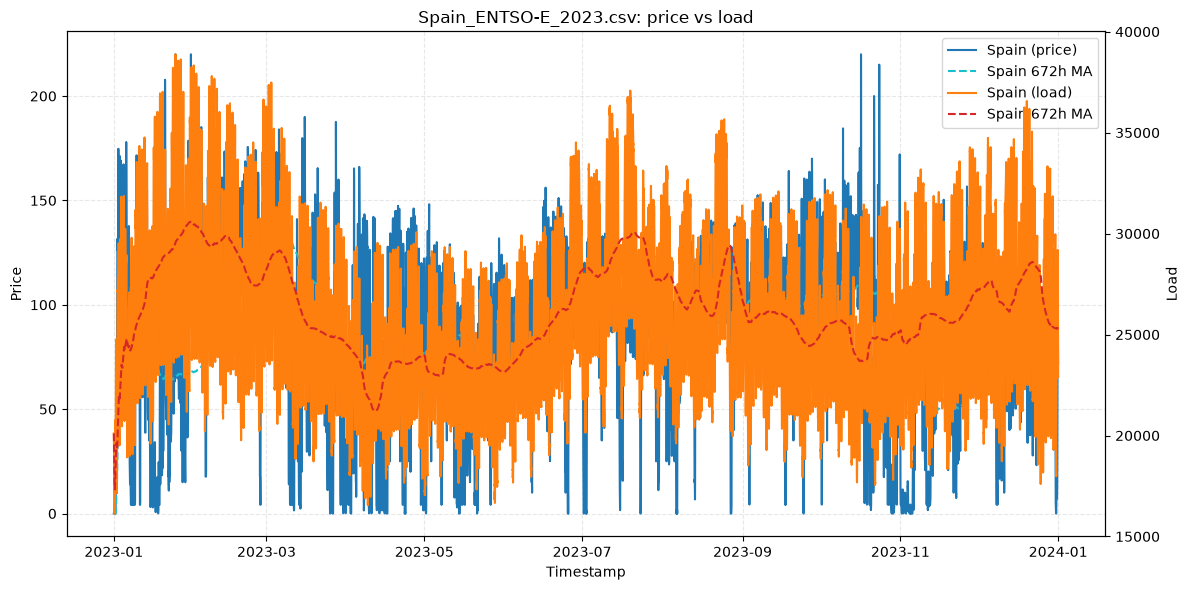

In [22]:
daep_content = daep_file.get("content_details", {})
download_url_daep = daep_content.get("download_url")

weld_content = weld_file.get("content_details", {})
download_url_weld = weld_content.get("download_url")
print("Download URL DAEP:", download_url_daep)
print("Download URL WELD:", download_url_weld)

r_daep = requests.get(download_url_daep, stream=True, timeout=10)
print("DAEP request:", r_daep.status_code)
r_weld = requests.get(download_url_weld, stream=True, timeout=10)
print("WELD request:", r_weld.status_code)

plot_df_daep = pd.read_csv(BytesIO(r_daep.content))
plot_df_daep["Timestamp"] = pd.to_datetime(plot_df_daep["Timestamp"], errors="coerce")

plot_df_weld = pd.read_csv(BytesIO(r_weld.content))
plot_df_weld["Timestamp"] = pd.to_datetime(plot_df_weld["Timestamp"], errors="coerce")

price_col = plot_df_daep.select_dtypes(include="number").columns[0]
load_col = plot_df_weld.select_dtypes(include="number").columns[0]


rolling_window = 24*28
ma_price_col = f"{price_col}_MA{rolling_window}"
plot_df_daep[ma_price_col] = plot_df_daep[price_col].rolling(window=rolling_window, min_periods=1).mean()

ma_load_col = f"{load_col}_MA{rolling_window}"
plot_df_weld[ma_load_col] = plot_df_weld[load_col].rolling(window=rolling_window, min_periods=1).mean()

fig, ax_price = plt.subplots(figsize=(12, 6))
line_price, = ax_price.plot(plot_df_daep["Timestamp"], plot_df_daep[price_col], color="tab:blue", label=f"{price_col} (price)")
line_price_ma, = ax_price.plot(plot_df_daep["Timestamp"], plot_df_daep[ma_price_col],
                               color="tab:cyan", linestyle="--", label=f"{price_col} {rolling_window}h MA")
ax_price.set_ylabel("Price")

ax_load = ax_price.twinx()
line_load, = ax_load.plot(plot_df_weld["Timestamp"], plot_df_weld[load_col], color="tab:orange", label=f"{load_col} (load)")
line_load_ma, = ax_load.plot(plot_df_weld["Timestamp"], plot_df_weld[ma_load_col],
                             color="tab:red", linestyle="--", label=f"{load_col} {rolling_window}h MA")
ax_load.set_ylabel("Load")

ax_price.set_title(f"{filename}: price vs load")
ax_price.set_xlabel("Timestamp")
ax_price.grid(True, linestyle="--", alpha=0.3)

lines = [line_price, line_price_ma, line_load, line_load_ma]
ax_price.legend(lines, [line.get_label() for line in lines], loc="best")

plt.tight_layout()

In [ ]:
weld_dataset_dir = os.path.join(DATASETS_DIR, "weld")
weld_pkl_dir = os.path.join(PKL_DIR, "weld")
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = os.path.join(ROOT, "datasets", "weld", "logs", f"{timestamp}_download_errors.log")

os.makedirs(weld_dataset_dir, exist_ok=True)
os.makedirs(weld_pkl_dir, exist_ok=True)

Downloading the full dataset via Mendeley API:

In [23]:
daep_dataset_dir = os.path.join(DATASETS_DIR, "daep")
daep_pkl_dir = os.path.join(ROOT, "pkl", "daep")
timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
daep_logs_dir = os.path.join(daep_dataset_dir, "logs", f"{timestamp}_download_errors.log")

os.makedirs(daep_dataset_dir, exist_ok=True)
os.makedirs(daep_pkl_dir, exist_ok=True)

In [24]:
results = []

daep_files = daep_data.get("files", [])

for f in daep_files:
    file_name = f.get("filename")
    content = f.get("content_details", {})

    if not file_name or content.get("content_type") != "text/csv":
        continue

    file_path = os.path.join(daep_dataset_dir, file_name)
    pickle_file = os.path.join(daep_pkl_dir, file_name.replace(".csv", ".pkl"))

    try:
        # skip download if CSV already exists
        if not os.path.exists(file_path):
            download_url = content.get("download_url")
            if not download_url:
                continue

            r = requests.get(download_url, stream=True, timeout=10)
            r.raise_for_status()

            with open(file_path, "wb") as fh:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        fh.write(chunk)

        df = pd.read_csv(file_path)
        record_count = len(df)

        results.append({"csv_name": file_name, "record_count": record_count})
        print(f"Processed {file_name} with {record_count} records.")
        clear_output(wait=True)

        if "Timestamp" in df.columns:
            df["Timestamp"] = pd.to_datetime(df["Timestamp"])

        os.makedirs(os.path.dirname(pickle_file), exist_ok=True)
        df.to_pickle(pickle_file)

    except Exception as e:
        with open(daep_logs_dir, "a", encoding="utf-8") as log:
            log.write(f"{file_name} | {type(e).__name__} | {e}\n")
        continue

csvs_df = pd.DataFrame(results)
csvs_df["pkl_name"] = csvs_df["csv_name"].str.replace(".csv", ".pkl")

display(csvs_df)

list_file_name = "0_daep_files_list.pkl"
csvs_df.to_pickle(os.path.join(daep_pkl_dir, list_file_name))
print(f"Saved file list to {os.path.join(daep_pkl_dir, list_file_name)}")

,csv_name,record_count,pkl_name
0,Additional_Information_by_Country.csv,49,Additional_Information_by_Country.pkl
1,Australia_AEMO_2006.csv,17519,Australia_AEMO_2006.pkl
2,Australia_AEMO_2007.csv,17520,Australia_AEMO_2007.pkl
3,Australia_AEMO_2008.csv,17568,Australia_AEMO_2008.pkl
4,Australia_AEMO_2009.csv,17520,Australia_AEMO_2009.pkl
...,...,...,...
501,USA_SPP_2021.csv,8759,USA_SPP_2021.pkl
502,USA_SPP_2022.csv,8759,USA_SPP_2022.pkl
503,USA_SPP_2023.csv,8759,USA_SPP_2023.pkl
504,USA_SPP_2024.csv,8778,USA_SPP_2024.pkl


Saved file list to ..\pkl\daep\0_daep_files_list.pkl
